In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cftime

In [2]:
# ---- example usage ----
era5 = xr.open_zarr("/glade/derecho/scratch/yqsun/PANGU-S2S/ERA5/era5-benchX",chunks={}).rename({"lat": "latitude", "lon": "longitude", "plev":"level"})
# era5 = xr.open_dataset("/project/pedramh/bing/PanguWeather/v2.0/data/2018_180x360.nc", chunks={}).expand_dims(plev=1).rename({"lat": "latitude", "lon": "longitude", "plev":"level"})
era5['latitude'] = era5['latitude'].astype("float32")
era5['longitude'] = era5['longitude'].astype("float32")
era5['level'] = era5['level'].astype("int32")
# # ---- example usage ----
# era5 = xr.open_dataset("/project/pedramh/bing/PanguWeather/v2.0/data/2018_180x360.nc", chunks={})
# era5 = era5.expand_dims(plev=1).rename({"lat": "latitude", "lon": "longitude", "plev":"level"})
def preprocess(ds):
    ens = np.int32(ds.encoding["source"].split("/")[-1].split(".")[0].split("_")[-1])
    ds = ds.expand_dims(dim={"number": [ens]})
    ds = ds.rename({"time":"prediction_timedelta"})
    ds = ds.expand_dims(dim={"time": [ds["prediction_timedelta"][0].values]})
    ds["prediction_timedelta"] = np.arange(0, 24*len(ds["prediction_timedelta"]), 24).astype("timedelta64[h]").astype("timedelta64[ns]")
    return ds

In [62]:
year=2020
ds = xr.open_zarr(f"/glade/campaign/univ/uchi0018/bing/gencast/gencast_{year}.zarr", decode_times=False, chunks={})

In [63]:
import pandas as pd
import datetime
def get_initialization_dates(year):
    """
    Get initialization dates (Calendar dates corresponding to 
    Mondays and Thursdays of 2024 May-July) for a given year.
    """
    # Define date range from May 1 to July 31 of 2024 (template)
    start_date = datetime.datetime(2024, 5, 1)
    end_date = datetime.datetime(2024, 7, 31)
    date_range = pd.date_range(start_date, end_date, freq='D')
    
    # Find Mondays (weekday=0) and Thursdays (weekday=3)
    is_monday = date_range.weekday == 0
    is_thursday = date_range.weekday == 3
    filtered_dates = date_range[is_monday | is_thursday]
    
    # Convert to the requested year
    filtered_dates_yr = pd.to_datetime(filtered_dates.strftime(f'{year}-%m-%d'))
    return filtered_dates_yr
dates= get_initialization_dates(year)

In [64]:
ds["time"] = dates

In [65]:
dates

DatetimeIndex(['2020-05-02', '2020-05-06', '2020-05-09', '2020-05-13',
               '2020-05-16', '2020-05-20', '2020-05-23', '2020-05-27',
               '2020-05-30', '2020-06-03', '2020-06-06', '2020-06-10',
               '2020-06-13', '2020-06-17', '2020-06-20', '2020-06-24',
               '2020-06-27', '2020-07-01', '2020-07-04', '2020-07-08',
               '2020-07-11', '2020-07-15', '2020-07-18', '2020-07-22',
               '2020-07-25', '2020-07-29'],
              dtype='datetime64[ns]', freq=None)

In [66]:
ds.sel(time = dates[0])
var = ds.sel(time=dates[19]) #"2019-07-18T00:00:00"
var = var.coarsen(lat=4, lon=4, boundary="trim").mean()
var = var.rename({"lat":"latitude", "lon":"longitude"})
precip_24h = var['total_precipitation_12hr'].rolling(step=2, center=False).sum().dropna(dim='step')

In [69]:
dates[19]

Timestamp('2020-07-08 00:00:00')

In [67]:
var_std = precip_24h.std(dim="sample")

In [ ]:
# date = "20190718"
# var = ds.sel(time="2019-07-18T00:00:00")
# var = var.coarsen(lat=4, lon=4, boundary="trim").mean()
# var = var.rename({"lat":"latitude", "lon":"longitude"})

In [14]:
var

<xarray.Dataset> Size: 52GB
Dimensions:                   (sample: 52, step: 90, latitude: 180,
                               longitude: 360, level: 10)
Coordinates:
  * latitude                  (latitude) float32 720B -89.62 -88.62 ... 89.38
  * level                     (level) int64 80B 200 250 300 400 ... 850 925 1000
  * longitude                 (longitude) float32 1kB 0.375 1.375 ... 359.4
  * sample                    (sample) int64 416B 0 1 2 3 4 5 ... 47 48 49 50 51
  * step                      (step) int64 720B 12 24 36 48 ... 1056 1068 1080
    time                      datetime64[ns] 8B 2019-07-18
Data variables:
    2m_temperature            (sample, step, latitude, longitude) float32 1GB dask.array<chunksize=(4, 90, 180, 360), meta=np.ndarray>
    sea_surface_temperature   (sample, step, latitude, longitude) float32 1GB dask.array<chunksize=(4, 90, 180, 360), meta=np.ndarray>
    specific_humidity         (sample, step, level, latitude, longitude) float32 12GB dask.array<chunksize=(4, 90, 1, 180, 360), meta=np.ndarray>
    temperature               (sample, step, level, latitude, longitude) float32 12GB dask.array<chunksize=(4, 90, 1, 180, 360), meta=np.ndarray>
    total_precipitation_12hr  (sample, step, latitude, longitude) float32 1GB dask.array<chunksize=(4, 90, 180, 360), meta=np.ndarray>
    u_component_of_wind       (sample, step, level, latitude, longitude) float32 12GB dask.array<chunksize=(4, 90, 1, 180, 360), meta=np.ndarray>
    v_component_of_wind       (sample, step, level, latitude, longitude) float32 12GB dask.array<chunksize=(4, 90, 1, 180, 360), meta=np.ndarray>

In [ ]:
# var_std = precip_24h.std(dim="sample")

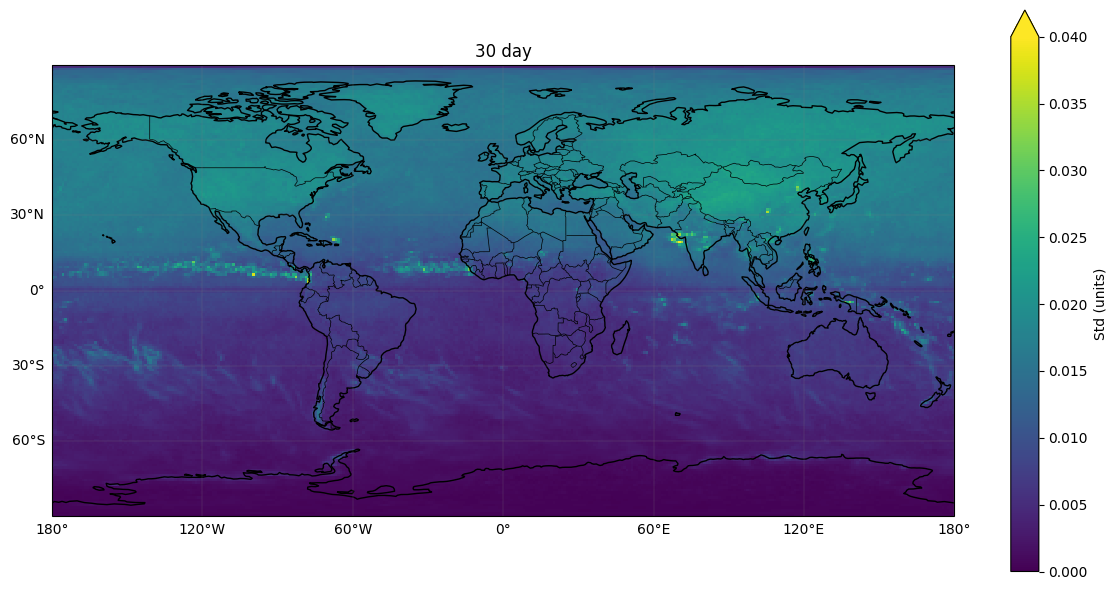

In [68]:
# ...existing code...
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(figsize=(12, 6), subplot_kw=dict(projection=ccrs.PlateCarree()))
# plot with explicit transform so Cartopy can place it correctly
im = var_std.isel(step=61).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    vmin=0,
    vmax=0.04,
    cmap="viridis",
    add_colorbar=True,
    cbar_kwargs={"label": "Std (units)"}
)

# add coastlines and optional features
ax.coastlines(resolution="110m", linewidth=1, color="black")
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.2)

# gridlines and labels
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
gl.top_labels = False
gl.right_labels = False

plt.title(f"30 day")
plt.tight_layout()
# plt.savefig(f"/glade/work/bgong/benchmark-dev/metrics/CRPS/{date}_varstd_map.png", dpi=300, bbox_inches="tight")
plt.show()
# ...existing code...

In [12]:
var= precip_24h

In [28]:
prediction_delta = var['step'] * np.timedelta64(1, 'h')
gt = era5.sel(time=(var.time + prediction_delta))["total_precipitation_24hr"]

In [29]:
gt

<xarray.DataArray 'total_precipitation_24hr' (step: 89, latitude: 180,
                                              longitude: 360)> Size: 23MB
dask.array<getitem, shape=(89, 180, 360), dtype=float32, chunksize=(89, 180, 360), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float32 720B -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * longitude  (longitude) float32 1kB 0.0 1.0 2.0 3.0 ... 357.0 358.0 359.0
    time       (step) datetime64[ns] 712B 2021-07-30 ... 2021-09-12
  * step       (step) int64 712B 24 36 48 60 72 84 ... 1032 1044 1056 1068 1080

In [30]:
var

<xarray.DataArray 'total_precipitation_12hr' (sample: 52, step: 89,
                                              latitude: 180, longitude: 360)> Size: 1GB
dask.array<getitem, shape=(52, 89, 180, 360), dtype=float32, chunksize=(2, 89, 90, 180), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float32 720B -89.62 -88.62 -87.62 ... 88.38 89.38
  * longitude  (longitude) float32 1kB 0.375 1.375 2.375 ... 357.4 358.4 359.4
  * sample     (sample) int64 416B 0 1 2 3 4 5 6 7 8 ... 44 45 46 47 48 49 50 51
  * step       (step) int64 712B 24 36 48 60 72 84 ... 1032 1044 1056 1068 1080
    time       datetime64[ns] 8B 2021-07-29

In [25]:
var.sel(sample=0).values

array([[[ 1.05121452e-03,  1.05030101e-03,  1.04986317e-03, ...,
          1.05271942e-03,  1.05216540e-03,  1.05174247e-03],
        [ 7.96013745e-04,  7.88691919e-04,  7.81582610e-04, ...,
          8.19666253e-04,  8.11822247e-04,  8.03949195e-04],
        [ 7.04348204e-04,  7.04809092e-04,  7.02348712e-04, ...,
          6.90681161e-04,  6.96717179e-04,  7.01572048e-04],
        ...,
        [ 3.30459094e-04,  3.27470334e-04,  3.26065987e-04, ...,
          3.41574545e-04,  3.38525278e-04,  3.33980250e-04],
        [ 3.45077075e-04,  3.52987903e-04,  3.60175065e-04, ...,
          3.21213913e-04,  3.29051778e-04,  3.36737547e-04],
        [ 2.90191500e-04,  2.90557946e-04,  2.90487660e-04, ...,
          2.87601491e-04,  2.88768613e-04,  2.89586897e-04]],

       [[ 1.01028138e-03,  1.00458064e-03,  9.99203650e-04, ...,
          1.02762342e-03,  1.02182687e-03,  1.01608422e-03],
        [ 7.67633435e-04,  7.62038631e-04,  7.56761525e-04, ...,
          7.85702141e-04,  7.79722061e

In [26]:
gt.values

array([[[234.40979, 234.37427, 234.33922, ..., 234.51476, 234.47948,
         234.44473],
        [233.60791, 233.56993, 233.53165, ..., 233.71436, 233.67287,
         233.6407 ],
        [231.99974, 232.0058 , 232.00629, ..., 231.86179, 231.90251,
         231.9523 ],
        ...,
        [273.9027 , 273.9015 , 273.90002, ..., 273.9013 , 273.90265,
         273.9027 ],
        [273.8798 , 273.87222, 273.86398, ..., 273.88434, 273.88348,
         273.88232],
        [273.8703 , 273.8669 , 273.86374, ..., 273.89246, 273.88434,
         273.87695]],

       [[230.21242, 230.17488, 230.13568, ..., 230.30869, 230.2774 ,
         230.24498],
        [230.08394, 230.06425, 230.04404, ..., 230.12427, 230.10873,
         230.09666],
        [229.25833, 229.28922, 229.30582, ..., 229.11604, 229.15855,
         229.20512],
        ...,
        [274.1827 , 274.2019 , 274.22574, ..., 274.19266, 274.1899 ,
         274.1856 ],
        [274.14996, 274.15244, 274.15472, ..., 274.14133, 274.14462,
   

In [42]:
rmse = np.sqrt(np.mean((var.sel(sample=0).values - gt.values)**2, axis=(1,2)))

In [43]:
rmse[::2]

array([0.932709 , 1.1215636, 1.3313937, 1.5497943, 1.9390914, 2.3557045,
       2.2573671, 2.4343672, 2.826869 , 3.3918397, 3.6526916, 3.6408088,
       3.5931056, 3.622366 , 3.5461192, 3.5079973, 3.666903 , 3.7599895,
       4.119846 , 4.504723 , 4.5197005, 4.310857 , 3.9643686, 3.856188 ,
       3.8116276, 4.2094164, 4.3258314, 3.9654615, 4.2445416, 4.4868054,
       4.462219 , 4.3671765, 3.9191551, 3.8508298, 3.5273645, 3.9575515,
       4.4407897, 4.3792014, 4.174095 , 4.275625 , 3.7290366, 3.9085815,
       4.02494  , 3.700727 , 3.5948708], dtype=float32)

Figure is saved


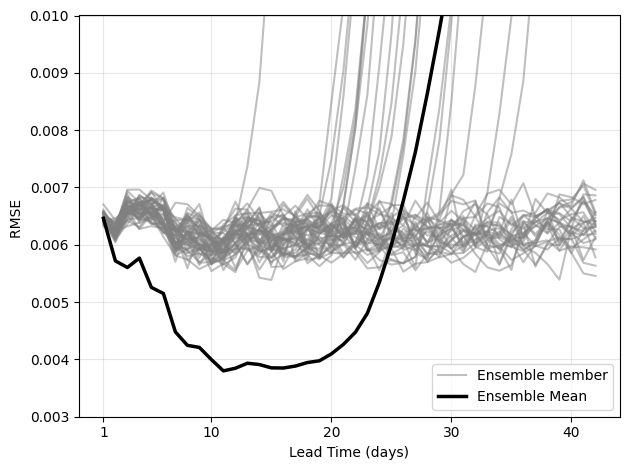

In [35]:
var_name="ttp"
fig, ax = plt.subplots()
x = np.arange(0, 42)
all_mem = []
for number in range(1,50):
   fcast = var.sel(sample=number).values
   tr = gt.values
   member_y = np.sqrt(np.mean((fcast -tr)**2, axis=(1,2)))
   if number ==1:
      ax.plot(x, member_y[1::2][:42], color='gray', alpha=0.5,label="Ensemble member")
   else:
      ax.plot(x, member_y[1::2][:42], color='gray', alpha=0.5)
   plt.ylim(0.003, 0.01) 
   all_mem.append(fcast)
ens_mean = np.array(all_mem).mean(axis=0)
member_ens = np.sqrt(np.mean((ens_mean - tr)**2, axis=(1,2)))

ax.plot(x, member_ens[::2][:42],  color='black', linewidth=2.5, label="Ensemble Mean")
plt.xticks([0, 9, 19, 29, 39], ["1", "10", "20", "30", "40"])

plt.xlabel("Lead Time (days)")
plt.ylabel("RMSE ")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.show()
plt.savefig(f"/glade/work/bgong/benchmark-dev/metrics/CRPS/gencast_{date}_{var_name}_ensemble_rmse.png", dpi=300, bbox_inches="tight")
print("Figure is saved")
plt.show()

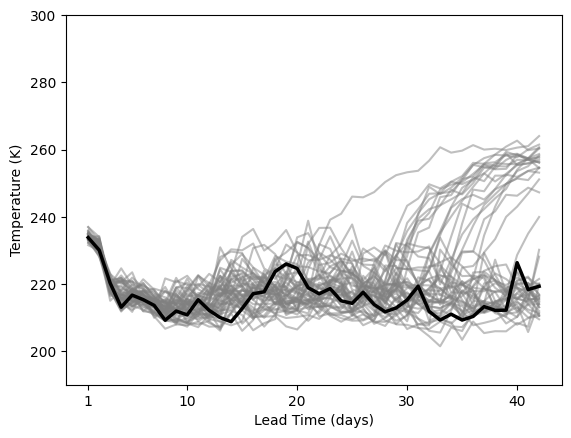

In [74]:
fig, ax = plt.subplots()
for m in range(50):
    member_y = var.sel(sample=m).isel(longitude=1,latitude=1).values[::2][:42]
    ax.plot(x, member_y, color='gray', alpha=0.5)
    # plt.ylim(0, 2500) 
    # rmse.append(member_y)
    # plt.ylim(44000, 60000)
    plt.ylim(190, 300) 
gt_mem = gt.isel(latitude=1,longitude=1).values[::2][:42]
ax.plot(x,gt_mem, color='black', linewidth=2.5, label="Ensemble Mean")
plt.xticks([0, 9, 19, 29, 39], ["1", "10", "20", "30", "40"])
plt.xlabel("Lead Time (days)")
# plt.ylabel(r'Geopotential (m$^2$/s$^2$)')
plt.ylabel("Temperature (K)")   # correct unit
plt.savefig(f"/glade/work/bgong/benchmark-dev/metrics/CRPS/gencast_{date}_{var_name}_location.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
#Generate ensemble mean

In [78]:
members_ens=[]
for date in dates:
    all_mem = []
    var = ds.sel(time=date)["2m_temperature"]
    prediction_delta = var['step'] * np.timedelta64(1, 'h')
    var = var.coarsen(lat=4, lon=4, boundary="trim").mean()
    var = var.rename({"lat":"latitude", "lon":"longitude"})
    gt = era5.sel(time=(var.time + prediction_delta))["2m_temperature"]
    for number in range(1,30):
        fcast = var.sel(sample=number).values
        tr = gt.values
        member_y = np.sqrt(np.mean((fcast -tr)**2, axis=(1,2)))
        all_mem.append(fcast)
    ens_mean = np.array(all_mem).mean(axis=0)
    member_ens = np.sqrt(np.mean((ens_mean - tr)**2, axis=(1,2)))
    members_ens.append(member_ens)
    
        
    
    